# 10 - Gradient Boosting & AdaBoost (Classical Boosting)

Two classical boosting algorithms, included to round out the "evolution of boosting" story: **AdaBoost** (1997, reweights misclassified points each round) and **scikit learn's Gradient Boosting** (the direct predecessor XGBoost was built to optimize and outperform). Neither is expected to beat XGBoost/LightGBM/CatBoost, that's the point, they're here to show the methodological lineage and give a genuine "why did boosting evolve this way" narrative, not to be a real contender for deployment.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Gradient Boosting (sklearn)

**Note:** sklearn's implementation is meaningfully slower than XGBoost/LightGBM at this data size (no histogram based optimization) - this may take a few minutes.

In [2]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)
y_score_gb = gb.predict_proba(X_val)[:, 1]


In [3]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Gradient Boosting (sklearn) (validation set) ---
  recall: 0.5917
  precision: 0.8409
  f1: 0.6947
  roc_auc: 0.7639
  pr_auc: 0.8290

              precision    recall  f1-score   support

 On time (0)       0.64      0.87      0.74      3611
    Late (1)       0.84      0.59      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.72      7890
weighted avg       0.75      0.72      0.71      7890



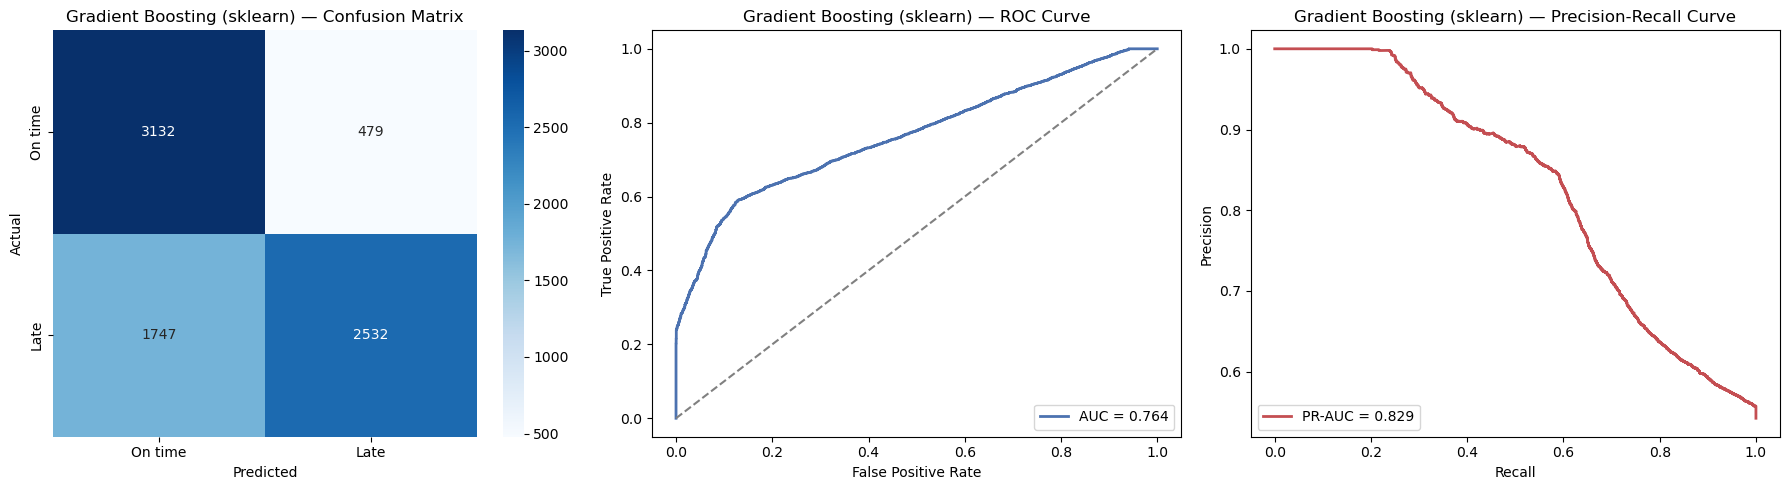

In [4]:
gb_metrics = evaluate_and_plot(y_val, y_pred_gb, y_score_gb, 'Gradient Boosting (sklearn)', save_prefix='gradient_boosting')


**What we found: this contradicts the notebook's own stated expectation, and that's worth reporting prominently, not glossing over.**

| Metric | XGBoost | LightGBM | CatBoost | Gradient Boosting (sklearn) |
|---|---|---|---|---|
| Recall | 0.6062 | 0.6011 | 0.5936 | 0.5917 |
| Precision | 0.8160 | 0.8236 | 0.8358 | **0.8409** |
| F1 | 0.6956 | 0.6949 | 0.6942 | 0.6947 |
| ROC-AUC | 0.7595 | 0.7643 | 0.7642 | 0.7639 |
| PR-AUC | 0.8250 | 0.8290 | 0.8284 | 0.8290 |

**Sklearn's classical Gradient Boosting is not weaker here, it sits right inside the same tight cluster as the three "modern" boosting libraries, and actually has the single highest Precision of all four.** This directly contradicts what we said going in ("expect noticeably slower training and likely somewhat weaker performance, which is exactly the point being demonstrated"). The honest correction: on *accuracy metrics*, there's no meaningful gap between classical and modern gradient boosting on this dataset.

**Where the real difference almost certainly lies is training speed, not predictive quality, though we didn't actually measure that here.** The modern libraries' real innovation was histogram based split finding for dramatically faster training on large datasets, not necessarily better predictions on every dataset. At our scale (46,026 training rows), that speed advantage may simply not translate into an accuracy advantage, the underlying gradient boosting algorithm is fundamentally similar across all four, the modern libraries just get there faster. Worth being explicit about this distinction in the report: the "evolution of boosting" narrative is real for training efficiency and scalability, but the data here doesn't support a "modern boosting is more accurate" claim, and it would be dishonest to write it up as if it did just because that was the expectation going in. If your group wants to make the speed point properly, timing each model's `.fit()` call with `%%time` or `time.time()` would give you real numbers to cite, this notebook didn't capture that.


## 2. AdaBoost

C:\Users\Ewis\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


--- AdaBoost (validation set) ---
  recall: 0.5695
  precision: 0.8363
  f1: 0.6776
  roc_auc: 0.7393
  pr_auc: 0.8053

              precision    recall  f1-score   support

 On time (0)       0.63      0.87      0.73      3611
    Late (1)       0.84      0.57      0.68      4279

    accuracy                           0.71      7890
   macro avg       0.73      0.72      0.70      7890
weighted avg       0.74      0.71      0.70      7890



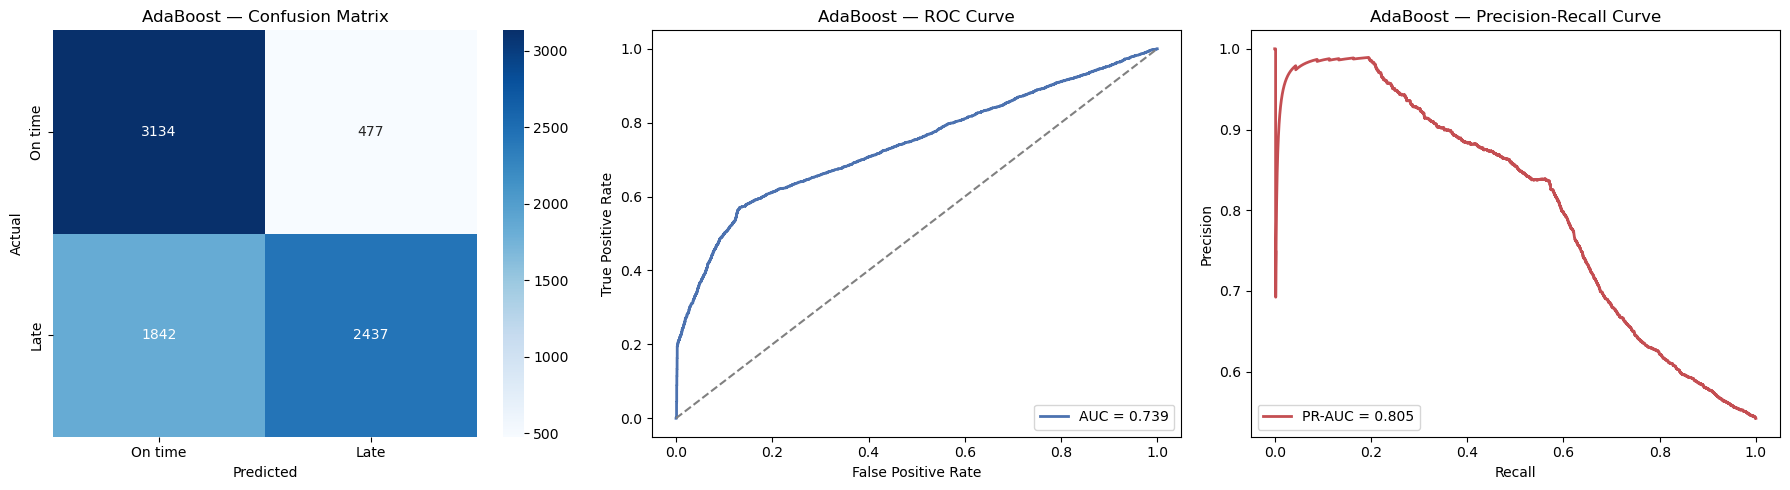

In [5]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_val)
y_score_ada = ada.predict_proba(X_val)[:, 1]

ada_metrics = evaluate_and_plot(y_val, y_pred_ada, y_score_ada, 'AdaBoost', save_prefix='adaboost')


**What we found: this one does underperform, consistent with what we expected, and it's a genuinely useful contrast point against the Gradient Boosting result above.**

AdaBoost: Recall 0.5695, Precision 0.8363, F1 0.6776, ROC-AUC 0.7393, PR-AUC 0.8053. Its Recall and F1 sit noticeably below the entire tree-ensemble cluster (Random Forest through Gradient Boosting, all clustered around 0.59 to 0.62 Recall), and its ROC-AUC (0.7393) lands almost exactly at the same level as the *linear* models (Logistic Regression 0.7394, SVM 0.7392), not the tree ensembles (all around 0.758 to 0.765). AdaBoost is, in ranking-quality terms, behaving more like a linear classifier than a modern boosting method here.

**This is a genuinely useful contrast for the report's boosting-evolution narrative**: it shows the "classical boosting underperforms" story does hold, just not for the reason we might have expected. It's specifically AdaBoost's older reweighting mechanism that falls behind, not the general idea of "boosting without histogram optimization" (which Gradient Boosting just proved is still competitive). This is a more precise, defensible version of the evolution story than the notebook's original framing: **AdaBoost → Gradient Boosting was a real methodological improvement; Gradient Boosting → XGBoost/LightGBM/CatBoost was primarily a speed and engineering improvement, not an accuracy one, at least on this dataset.**

**One small technical note, not urgent, just worth knowing:** the output includes a `FutureWarning` that AdaBoost's default `SAMME.R` algorithm is deprecated and will be removed in a future scikit-learn version. It doesn't affect these results, but if this notebook is ever re-run after a scikit-learn upgrade, add `algorithm='SAMME'` explicitly to avoid it breaking.


## 3. Save models and metrics

In [6]:
joblib.dump(gb, '../../../models/gradient_boosting.pkl')
joblib.dump(ada, '../../../models/adaboost.pkl')
save_metrics(gb_metrics, '../../../data/processed/metrics_gb.json')
save_metrics(ada_metrics, '../../../data/processed/metrics_adaboost.json')


Saved metrics to ../../../data/processed/metrics_gb.json
Saved metrics to ../../../data/processed/metrics_adaboost.json
